# Compare cumulative target methods

This notebook reuses the forecast scenario from Notebook 04c and compares three cumulative target constructions with explicit assumptions. Each target enters the same inventory replay on held-out demand.


In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statistics import NormalDist
from smooth import ES

from stockcast import InventoryStateDataFrame, OrderUpToPolicy, SimulationEngine
from stockcast.evaluation import (
    InventoryEvaluator, avg_on_hand, demand_period_service_level,
    fill_rate, order_units,
)


In [2]:
# Reuse the 04 tea scenario so this comparison starts from a known handoff.
sku = 'tea_250g'
forecast_origin = pd.Timestamp('2026-02-14')
period_frequency = 'D'
lead_time = 2
review_period = 2
service_level = 0.95
# An (R, S) target protects lead-time demand plus the next review interval.
protection_horizon = lead_time + review_period


## 1. Split history from held-out demand

Same ten observed days and twelve held-out days as Notebook 04c. The history fits the one shared forecast; the holdout becomes the realized simulation demand.


In [3]:
# Only these observations are available when the forecast is created.
history = pd.DataFrame({
    'unique_id': [sku] * 10,
    'date': pd.date_range(end=forecast_origin, periods=10, freq=period_frequency),
    'y': [5.0, 6.0, 4.0, 7.0, 6.0, 5.0, 8.0, 6.0, 5.0, 7.0],
})

# The holdout is kept separate and later becomes realized simulation demand.
holdout_values = [7.0, 5.0, 8.0, 6.0, 4.0, 7.0, 6.0, 9.0, 5.0, 6.0, 7.0, 5.0]
holdout = pd.DataFrame({
    'unique_id': [sku] * len(holdout_values),
    'period': range(len(holdout_values)),
    'date': pd.date_range(
        forecast_origin + pd.Timedelta(days=1),
        periods=len(holdout_values),
        freq=period_frequency,
    ),
    'y': holdout_values,
})


In [4]:
# Ten observed days end exactly at the forecast origin.
assert history['date'].max() == forecast_origin
assert len(history) == 10

history


,unique_id,date,y
0,tea_250g,2026-02-05,5.0
1,tea_250g,2026-02-06,6.0
2,tea_250g,2026-02-07,4.0
3,tea_250g,2026-02-08,7.0
4,tea_250g,2026-02-09,6.0
5,tea_250g,2026-02-10,5.0
6,tea_250g,2026-02-11,8.0
7,tea_250g,2026-02-12,6.0
8,tea_250g,2026-02-13,5.0
9,tea_250g,2026-02-14,7.0


In [5]:
# Twelve held-out days begin the day after the origin and never overlap history.
assert holdout['date'].min() == forecast_origin + pd.Timedelta(days=1)
assert holdout['date'].min() > history['date'].max()
assert len(holdout) == 12

holdout


,unique_id,period,date,y
0,tea_250g,0,2026-02-15,7.0
1,tea_250g,1,2026-02-16,5.0
2,tea_250g,2,2026-02-17,8.0
3,tea_250g,3,2026-02-18,6.0
4,tea_250g,4,2026-02-19,4.0
5,tea_250g,5,2026-02-20,7.0
6,tea_250g,6,2026-02-21,6.0
7,tea_250g,7,2026-02-22,9.0
8,tea_250g,8,2026-02-23,5.0
9,tea_250g,9,2026-02-24,6.0


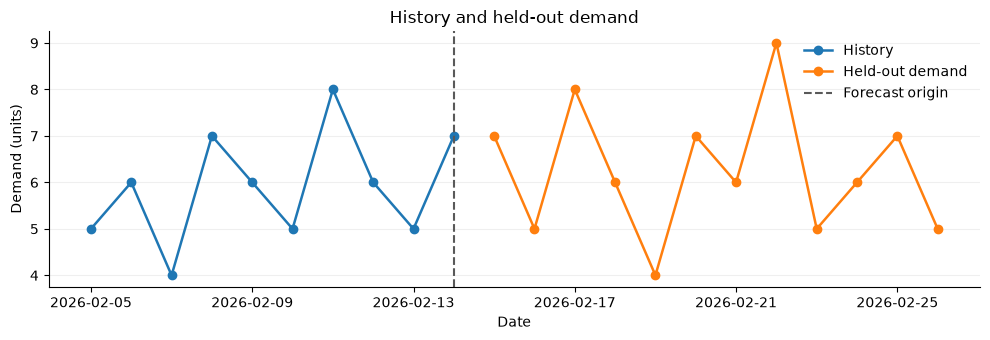

In [6]:
# Plot the data boundary before fitting the forecasting model.
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(history['date'], history['y'], marker='o', linewidth=1.8, label='History')
ax.plot(holdout['date'], holdout['y'], marker='o', linewidth=1.8, label='Held-out demand')
ax.axvline(forecast_origin, color='0.35', linestyle='--', label='Forecast origin')
ax.set(title='History and held-out demand', xlabel='Date', ylabel='Demand (units)')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()


## 2. Fit once, then construct three targets

A single `ES(model='ANN')` fit uses the observed history. This optional example uses `smooth==1.0.7` on Python 3.11+. Smooth's ES class fixes the error distribution to Gaussian (`dnorm`); that assumption needs checking for real demand. Method A adds an independence assumption; Methods B and C request the cumulative forecast directly from the external model.


In [7]:
# One univariate fit on the observed history; every method reuses this object.
model = ES(model='ANN')  # ES fixes the error distribution to dnorm.
model.fit(history['y'])

# Daily means and upper bounds stay separate here: they are marginals, not the target.
daily_forecast = model.predict(
    h=protection_horizon,
    interval='prediction',
    level=service_level,
    side='upper',
    cumulative=False,
)

forecast_dates = pd.date_range(
    forecast_origin + pd.Timedelta(days=1),
    periods=protection_horizon,
    freq=period_frequency,
)
daily_forecast_output = pd.DataFrame({
    'date': forecast_dates,
    'forecast_mean': daily_forecast.mean.to_numpy(),
    'daily_upper_95': daily_forecast.upper.iloc[:, 0].to_numpy(),
    'heldout_demand': holdout.loc[:protection_horizon - 1, 'y'].to_numpy(),
})


In [8]:
# Four daily means with separate upper bounds, beside demand later observed.
print(daily_forecast_output.to_string(index=False, float_format=lambda value: f'{value:.3f}'))


      date  forecast_mean  daily_upper_95  heldout_demand
2026-02-15          5.900           7.989           7.000
2026-02-16          5.900           7.989           5.000
2026-02-17          5.900           7.989           8.000
2026-02-18          5.900           7.989           6.000


### Method A: independent-normal aggregation inside Stockcast

For Gaussian marginal forecasts, recover each daily standard deviation as `sigma = (q95 - mean) / z`. Stockcast calculates `S = sum(mean) + z * sqrt(sum(sigma^2))` under the explicit assumption of independent daily forecast errors.

Gaussian marginals alone do not establish independence. This separate approximation is recorded as `independent_normal_marginals` in the policy metadata. Use it only when independence is defensible; the direct methods below use the external model's joint forecast.


In [9]:
# z converts each upper bound back into the sigma it implies under normality.
z = NormalDist().inv_cdf(service_level)
marginal_inputs = pd.DataFrame({
    'unique_id': [sku] * protection_horizon,
    'fh': range(1, protection_horizon + 1),
    'date': forecast_dates,
    'mean': daily_forecast_output['forecast_mean'].to_numpy(),
    'std': ((daily_forecast_output['daily_upper_95'] - daily_forecast_output['forecast_mean']) / z).to_numpy(),
})
policy_independent = OrderUpToPolicy(
    lead_time=lead_time,
    review_period=review_period,
    service_level=service_level,
    allow_backorders=False,
).fit(
    marginal_inputs,
    mean_column='mean',
    std_column='std',
    target_probability=service_level,
    protection_horizon=protection_horizon,
    aggregation_method='independent_normal',
    forecast_origin=forecast_origin,
    forecast_frequency=period_frequency,
    forecast_date_column='date',
)

print('Independent-normal inputs')
print(marginal_inputs.to_string(index=False, float_format=lambda value: f'{value:.3f}'))
print('\nFitted target')
print(policy_independent.get_target_levels().round(3).to_string(index=False))
print('\nTarget metadata')
print(pd.DataFrame([policy_independent.get_target_metadata()]).to_string(index=False))


Independent-normal inputs
unique_id  fh       date  mean   std
 tea_250g   1 2026-02-15 5.900 1.270
 tea_250g   2 2026-02-16 5.900 1.270
 tea_250g   3 2026-02-17 5.900 1.270
 tea_250g   4 2026-02-18 5.900 1.270

Fitted target
unique_id  target_level
 tea_250g        27.777

Target metadata


              representation  target_probability  protection_horizon        target_source     forecast_origin forecast_frequency     target_end_date calculation_method
independent_normal_marginals                0.95                   4 built_in_calculation 2026-02-14T00:00:00                  D 2026-02-18T00:00:00 independent_normal


### Methods B and C: external cumulative forecasts

With `cumulative=True`, Smooth's `approximate` route estimates an upper bound for total demand. Its `simulated` route generates joint future paths and estimates the quantile of their cumulative totals.

The simulated result has Monte Carlo variability. Smooth 1.0.7 ignores its prediction seed argument for `interval='simulated'`, so repeated runs can differ. Retain generated targets and forecasting settings for replay; the inventory engine's seed does not seed the external forecast. Agreement here is a diagnostic, not proof of calibration.


In [10]:
# Two calls, same question: the 95% upper bound of the four-day total.
cumulative_approx = model.predict(
    h=protection_horizon,
    interval='approximate',
    level=service_level,
    side='upper',
    cumulative=True,
)
cumulative_sim = model.predict(
    h=protection_horizon,
    interval='simulated',
    level=service_level,
    side='upper',
    cumulative=True,
    nsim=5000,
)
approx_target = float(cumulative_approx.upper.iloc[-1, 0])
sim_target = float(cumulative_sim.upper.iloc[-1, 0])
cumulative_mean = float(cumulative_approx.mean.iloc[-1])
print(f'Direct approximate upper 95%: {approx_target:.3f}')
print(f'Simulated upper 95% (5000 paths): {sim_target:.3f}')

# Report Monte Carlo differences without requiring stochastic agreement.
print(f'Simulated minus approximate: {sim_target - approx_target:.3f}')


Direct approximate upper 95%: 27.777
Simulated upper 95% (5000 paths): 28.288
Simulated minus approximate: 0.511


## 3. Compare the three targets

Horizon and requested probability are shared. Differences reflect the independence approximation, the external cumulative calculation, and Monte Carlo error. The dashed line is the subsequently observed four-day demand total. One realization cannot establish 95% forecast coverage.


In [11]:
indep_target = float(policy_independent.get_target_levels().loc[0, 'target_level'])
comparison_targets = pd.DataFrame([
    {'method': 'A: independent-normal', 'protection_target': indep_target,
     'construction': 'sum(mean) + z * sqrt(sum(sigma^2))'},
    {'method': 'B: direct approximate', 'protection_target': approx_target,
     'construction': "model covariance of the total"},
    {'method': 'C: simulated (5000 paths)', 'protection_target': sim_target,
     'construction': 'quantile of summed joint paths'},
])
realized_total = float(holdout.loc[:protection_horizon - 1, 'y'].sum())

# Validate targets; realized coverage is an outcome.
assert np.isfinite(comparison_targets['protection_target']).all()
assert comparison_targets['protection_target'].ge(0).all()
comparison_targets['covers_realized_total'] = comparison_targets['protection_target'].ge(realized_total)

comparison_targets.round(3)


,method,protection_target,construction,covers_realized_total
0,A: independent-normal,27.777,sum(mean) + z * sqrt(sum(sigma^2)),True
1,B: direct approximate,27.777,model covariance of the total,True
2,C: simulated (5000 paths),28.288,quantile of summed joint paths,True


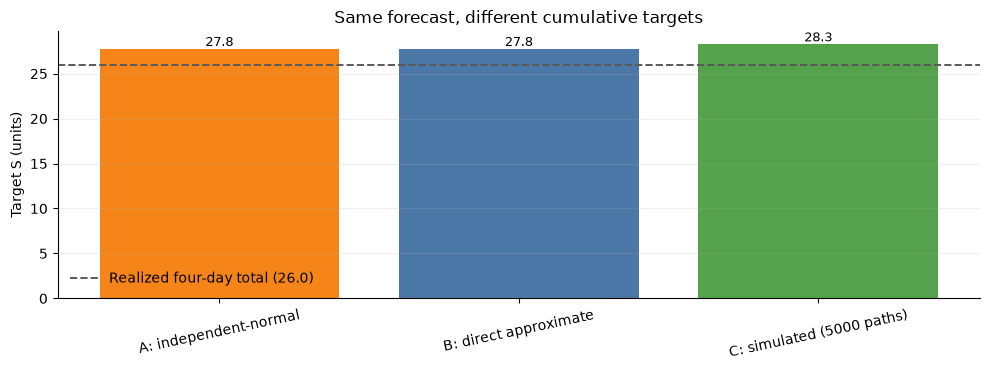

In [12]:
# Bars suit a categorical comparison; the line marks demand later observed.
fig, ax = plt.subplots(figsize=(10, 3.8))
bars = ax.bar(
    comparison_targets['method'], comparison_targets['protection_target'],
    color=['#F58518', '#4C78A8', '#54A24B'],
)
ax.axhline(realized_total, color='0.35', linestyle='--', linewidth=1.4,
           label=f'Realized four-day total ({realized_total:.1f})')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)
ax.set(title='Same forecast, different cumulative targets', ylabel='Target S (units)')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', rotation=12)
fig.tight_layout()
plt.show()


## 4. Replay the targets on the same demand

Each target becomes a fitted `(R, S)` policy with the same lead time, review period, and target probability. All three branches use identical held-out demand, opening stock, timing, and scoring windows.

Targets remain fixed to isolate their inventory consequences; Notebook 04cd shows rolling forecast updates. A 95% demand target does not guarantee a 95% realized fill rate.


In [13]:
# Pass external cumulative targets with explicit probability, horizon, and dates.
def direct_policy(target_value):
    frame = pd.DataFrame({
        'unique_id': [sku],
        'protection_target': [target_value],
        'target_end_date': [forecast_dates[-1]],
    })
    return OrderUpToPolicy(
        lead_time=lead_time,
        review_period=review_period,
        service_level=service_level,
        allow_backorders=False,
    ).fit(
        frame,
        target_column='protection_target',
        target_probability=service_level,
        protection_horizon=protection_horizon,
        target_source='external_direct',
        forecast_origin=forecast_origin,
        forecast_frequency=period_frequency,
        target_end_date_column='target_end_date',
    )

policy_approx = direct_policy(approx_target)
policy_simulated = direct_policy(sim_target)

fitted_levels = pd.DataFrame([
    {'method': 'A: independent-normal',
     'target_level': float(policy_independent.get_target_levels().loc[0, 'target_level'])},
    {'method': 'B: direct approximate',
     'target_level': float(policy_approx.get_target_levels().loc[0, 'target_level'])},
    {'method': 'C: simulated (5000 paths)',
     'target_level': float(policy_simulated.get_target_levels().loc[0, 'target_level'])},
])
print('Fitted target levels entering the replay')
print(fitted_levels.round(3).to_string(index=False))


Fitted target levels entering the replay
                   method  target_level
    A: independent-normal        27.777
    B: direct approximate        27.777
C: simulated (5000 paths)        28.288


In [14]:
# Opening stock is a declared inventory input, independent of the forecast.
opening_stock = pd.DataFrame({'unique_id': [sku], 'observed_on_hand': [12.0]})
opening_stock


,unique_id,observed_on_hand
0,tea_250g,12.0


In [15]:
# The engine deep-copies this state per branch; the caller-owned object is preserved.
opening_inventory = InventoryStateDataFrame(
    [sku], max_lead_time=lead_time, allow_backorders=False
).initialize_from_observed(
    opening_stock,
    on_hand_column='observed_on_hand',
    start_date=forecast_origin,
)
opening_inventory


InventoryStateDataFrame(n_skus=1, total_on_hand=12, total_safety_stock=0, total_backorders=0, has_stockout=False, has_backorder=False)

In [16]:
# Three branches, one shared demand calendar and timing contract.
comparison = SimulationEngine().run_comparison(
    policies=[policy_independent, policy_approx, policy_simulated],
    labels=[
        'A: independent-normal',
        'B: direct approximate',
        'C: simulated',
    ],
    demand_source=holdout,
    inventory=opening_inventory,
    n_periods=len(holdout),
    period_frequency=period_frequency,
    # Place the first policy order before the first held-out demand arrives.
    initial_decision='none',
    # Score the same twelve held-out days as Notebook 04c.
    warmup_periods=0,
    scoring_periods=len(holdout),
    settlement_periods=0,
    order_during_settlement=False,
    demand_source_name='declared_heldout_tea_demand',
    random_seed=None,
)

print('Scoring summaries by construction')
for label, branch in comparison.results.items():
    print(f'\n{label}')
    print(pd.DataFrame([branch.summary()]).round(3).to_string(index=False))


Scoring summaries by construction

A: independent-normal
 fill_rate  demand_period_service_level  mean_ending_on_hand_per_sku_period  stockout_periods  total_order_units  order_event_count  sku_order_line_count
       1.0                          1.0                               5.315                 0             78.777                  6                     6

B: direct approximate
 fill_rate  demand_period_service_level  mean_ending_on_hand_per_sku_period  stockout_periods  total_order_units  order_event_count  sku_order_line_count
       1.0                          1.0                               5.315                 0             78.777                  6                     6

C: simulated
 fill_rate  demand_period_service_level  mean_ending_on_hand_per_sku_period  stockout_periods  total_order_units  order_event_count  sku_order_line_count
       1.0                          1.0                                5.74                 0             79.288                  6     

## 5. Read the inventory outcomes

One evaluation contract — same scoring window, same pooled metrics — applied to every branch. These are units and service measures on declared synthetic demand, so no cost rate or operational claim follows.


In [17]:
# InventoryEvaluator reads validated scoring events from each branch.
metric_rows = []
for label, branch in comparison.results.items():
    row = InventoryEvaluator().fit(
        branch, window='scoring',
    ).evaluate(
        metrics=[fill_rate, demand_period_service_level, avg_on_hand, order_units],
        groupby=[],
    ).iloc[0].to_dict()
    row['method'] = label
    metric_rows.append(row)
metrics_table = pd.DataFrame(metric_rows).set_index('method')
print(metrics_table.round(3).to_string())


                       fill_rate  demand_period_service_level  avg_on_hand  order_units
method                                                                                 
A: independent-normal        1.0                          1.0        5.315       78.777
B: direct approximate        1.0                          1.0        5.315       78.777
C: simulated                 1.0                          1.0        5.740       79.288


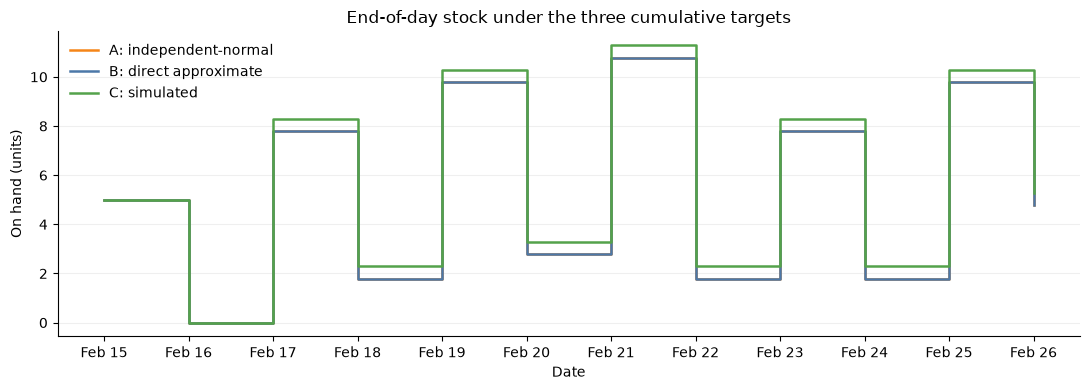

In [18]:
# Step lines show end-of-day stock: receipts arrive first, then demand is served.
fig, ax = plt.subplots(figsize=(11, 4))
branch_colors = {
    'A: independent-normal': '#F58518',
    'B: direct approximate': '#4C78A8',
    'C: simulated': '#54A24B',
}
for label, branch in comparison.results.items():
    branch_periods = branch.to_event_frame(window='all')
    branch_periods = branch_periods.loc[branch_periods['event_type'].eq('period')]
    ax.step(branch_periods['date'], branch_periods['ending_on_hand'], where='post',
            color=branch_colors[label], linewidth=1.8, label=label)
ax.set(title='End-of-day stock under the three cumulative targets', xlabel='Date', ylabel='On hand (units)')
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()


## Takeaway

Choose a cumulative target construction whose assumptions fit the demand process. Stockcast aggregates explicitly independent Gaussian moments; external tools can supply approximate or simulated cumulative targets with explicit dates, horizon, and probability.

For an external bootstrap workflow, generate coherent future-demand paths, total each path over the protection horizon, and take the desired quantile across those totals. Preserve relevant dependence and use only information available at the forecast origin. The resulting target uses the same direct handoff shown here.

Stockcast validates the handoff and accounts for inventory outcomes. Forecast calibration and suitability of the uncertainty model require separate held-out evidence.
